In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/puneet6060/intel-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


100%|██████████| 346M/346M [00:05<00:00, 63.1MB/s] 


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
device




'cpu'

In [3]:
from pathlib import Path
data_dir = Path("/content/intel-image-classification/seg_test/seg_test")
classes = [f.name for f in data_dir.iterdir() if f.is_dir()]
print(f"Found {len(classes)} classes: {classes}")







Found 6 classes: ['buildings', 'forest', 'street', 'sea', 'mountain', 'glacier']


In [4]:
!ls /content/

intel-image-classification  sample_data


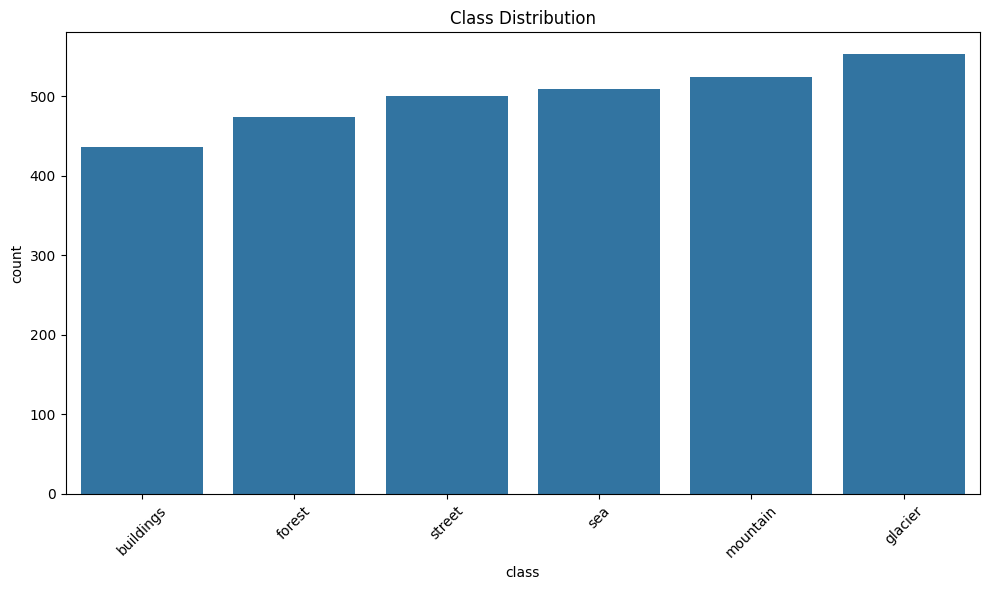

In [5]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = Path("/content/intel-image-classification/seg_test/seg_test")
class_counts = {}

for cls in classes:
    cls_dir = base_dir / cls
    images = list(cls_dir.glob("*.jpg"))
    class_counts[cls] = len(images)

df_counts = pd.DataFrame(list(class_counts.items()), columns=["class", "count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_counts.sort_values(by="count").head(20), x="class", y="count",)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.tight_layout()




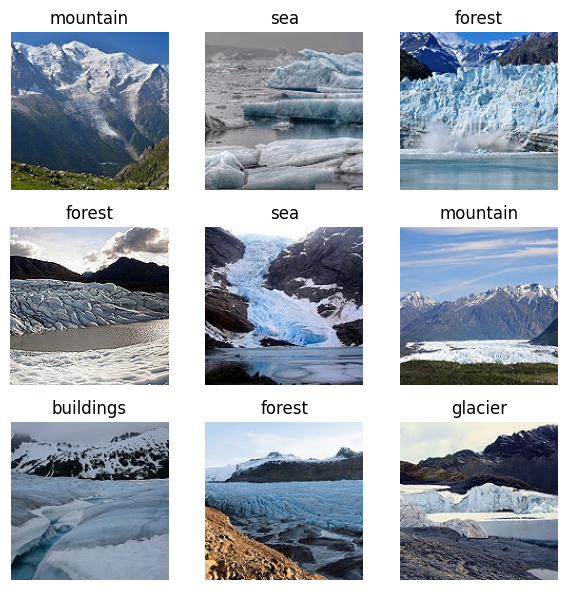

In [6]:
fig,ax = plt.subplots(3,3,figsize=(6,6))
for axes in ax.flat:
    random_cls = random.choice(classes)
    image_path = list(cls_dir.glob("*.jpg"))

    if not image_path:
        axes.set_title(f"No image found for {random_cls}")
        axes.axis("off")
        continue
    
    random_image_path = random.choice(image_path)
    image = Image.open(random_image_path)
    axes.imshow(image)
    axes.set_title(random_cls)
    axes.axis("off")
plt.tight_layout()
plt.show()

In [9]:
!ls /content/intel-image-classification/seg_test/seg_test

buildings  forest  glacier  mountain  sea  street


In [10]:
!ls /content/intel-image-classification/seg_train/seg_train

buildings  forest  glacier  mountain  sea  street
